In [52]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

In [45]:
X, y = make_classification(
    n_samples=1000,
    n_features=29,
    random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [46]:
rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42).fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_scores = rf.predict_proba(X_test)[:,1]

In [47]:
accuracy_score(y_test, y_pred)

0.8833333333333333

In [48]:
fpr, tpr, thresh = roc_curve(y_true=y_test, y_score=y_scores)
roc_auc = auc(fpr, tpr)
roc_auc

np.float64(0.9447384806973848)

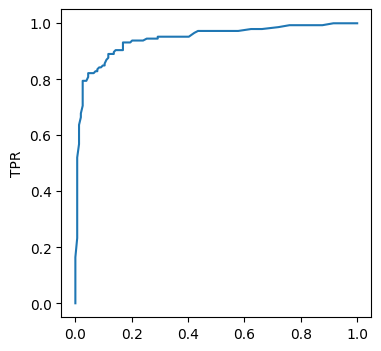

In [58]:
plt.figure(figsize=(4,4))
plt.plot(fpr, tpr)
plt.ylabel("TPR")
plt.show()

In [54]:
df = pd.read_table("Lab Files\\resources\\course3\\assets\\fruit_data_with_colors.txt")
X = df[df.columns[3:6]] # mass, width, height
y = df[df.columns[0]] # fruit_label
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

rf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42).fit(X_train, y_train)

importances = rf.feature_importances_
feature_names = X_train.columns

pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

,Feature,Importance
0,mass,0.357254
1,width,0.329384
2,height,0.313362


In [55]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, roc_auc_score, average_precision_score

# 1) Base model
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,                # use all cores
    # class_weight="balanced" # uncomment for imbalanced targets
)

# 2) Your parameter grid (tweak 'auto' if needed)
params = {
    "n_estimators": [100, 200, 500],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]  # prefer explicit values over "auto"
}

# 3) CV + scoring
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# choose a scoring metric — examples:
scoring = "roc_auc"               # needs predict_proba
# scoring = "f1"                  # if you want F1
# scoring = "recall"              # if you care about sensitivity
# scoring = "average_precision"   # PR AUC, great for imbalanced data

# 4) Grid search
grid = GridSearchCV(
    estimator=rf,
    param_grid=params,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True       # refit on full training data with best params
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV {scoring}: {grid.best_score_:.3f}")

best_rf = grid.best_estimator_
best_rf

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


c:\Users\shurai\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
c:\Users\shurai\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan

Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV roc_auc: nan
